# **Experiment 2**

Comparative Study of Regularization Techniques using Logistic Regression and Neural Networks

In [1]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_breast_cancer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import roc_auc_score
from sklearn.metrics import roc_curve

import tensorflow as tf

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.regularizers import l2

In [2]:
dataset = load_breast_cancer()

df = pd.DataFrame(dataset.data, columns=dataset.feature_names)
df["Target"] = dataset.target

df.head()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,Target
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0


In [3]:
cancer = load_breast_cancer()

print("Target Classes:")
print(cancer.target_names)

Target Classes:
['malignant' 'benign']


Dataset Shape: (569, 31)

Missing Values in Dataset


,0
mean radius,0
mean texture,0
mean perimeter,0
mean area,0
mean smoothness,0
mean compactness,0
mean concavity,0
mean concave points,0
mean symmetry,0
mean fractal dimension,0



Target Class Distribution


,count
Target,
1,357
0,212


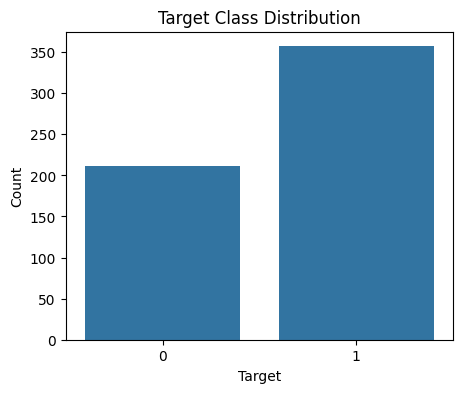

In [4]:
print("Dataset Shape:", df.shape)

print("\nMissing Values in Dataset")
display(df.isnull().sum())

print("\nTarget Class Distribution")
display(df["Target"].value_counts())

plt.figure(figsize=(5,4))
sns.countplot(x="Target", data=df)

plt.title("Target Class Distribution")
plt.xlabel("Target")
plt.ylabel("Count")

plt.show()

In [5]:
X = df.drop("Target", axis=1)
y = df["Target"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

print("Training Data Shape :", X_train.shape)
print("Testing Data Shape :", X_test.shape)

Training Data Shape : (455, 30)
Testing Data Shape : (114, 30)


In [6]:
result = []

def evaluate_model(model_name, model, X_train, X_test, y_train, y_test):

    train_prediction = model.predict(X_train)
    test_prediction = model.predict(X_test)

    train_accuracy = accuracy_score(y_train, train_prediction)
    test_accuracy = accuracy_score(y_test, test_prediction)

    precision = precision_score(y_test, test_prediction)
    recall = recall_score(y_test, test_prediction)
    f1 = f1_score(y_test, test_prediction)

    overfit_gap = train_accuracy - test_accuracy

    cm = confusion_matrix(y_test, test_prediction)

    print(f"\n{model_name}")
    print("-" * 40)
    print("Train Accuracy :", train_accuracy)
    print("Test Accuracy  :", test_accuracy)
    print("Precision      :", precision)
    print("Recall         :", recall)
    print("F1 Score       :", f1)

    print("\nConfusion Matrix")
    print(cm)

    result.append([
        model_name,
        train_accuracy,
        test_accuracy,
        precision,
        recall,
        f1,
        overfit_gap
    ])

In [7]:
lr_model = LogisticRegression(
    penalty=None,
    max_iter=5000,
    random_state=42
)

lr_model.fit(X_train, y_train)

evaluate_model(
    "Logistic Regression",
    lr_model,
    X_train,
    X_test,
    y_train,
    y_test
)


Logistic Regression
----------------------------------------
Train Accuracy : 1.0
Test Accuracy  : 0.9385964912280702
Precision      : 0.9848484848484849
Recall         : 0.9154929577464789
F1 Score       : 0.948905109489051

Confusion Matrix
[[42  1]
 [ 6 65]]


In [8]:
lr_l1_model = LogisticRegression(
    penalty="l1",
    solver="liblinear",
    C=1.0,
    max_iter=5000,
    random_state=42
)

lr_l1_model.fit(X_train, y_train)

evaluate_model(
    "Logistic Regression (L1)",
    lr_l1_model,
    X_train,
    X_test,
    y_train,
    y_test
)


Logistic Regression (L1)
----------------------------------------
Train Accuracy : 0.989010989010989
Test Accuracy  : 0.9736842105263158
Precision      : 0.9857142857142858
Recall         : 0.971830985915493
F1 Score       : 0.9787234042553191

Confusion Matrix
[[42  1]
 [ 2 69]]


In [9]:
lr_l2_model = LogisticRegression(
    penalty="l2",
    solver="liblinear",
    C=1.0,
    max_iter=5000,
    random_state=42
)

lr_l2_model.fit(X_train, y_train)

evaluate_model(
    "Logistic Regression (L2)",
    lr_l2_model,
    X_train,
    X_test,
    y_train,
    y_test
)


Logistic Regression (L2)
----------------------------------------
Train Accuracy : 0.9868131868131869
Test Accuracy  : 0.9736842105263158
Precision      : 0.9722222222222222
Recall         : 0.9859154929577465
F1 Score       : 0.9790209790209791

Confusion Matrix
[[41  2]
 [ 1 70]]


In [10]:
def build_model(use_dropout=False, use_batchnorm=False, use_l2=False):

    regularizer = l2(0.001) if use_l2 else None

    model = Sequential()

    model.add(Dense(
        64,
        activation="relu",
        kernel_regularizer=regularizer,
        input_shape=(30,)
    ))

    if use_batchnorm:
        model.add(BatchNormalization())

    if use_dropout:
        model.add(Dropout(0.5))

    model.add(Dense(
        32,
        activation="relu",
        kernel_regularizer=regularizer
    ))

    if use_batchnorm:
        model.add(BatchNormalization())

    if use_dropout:
        model.add(Dropout(0.5))

    model.add(Dense(1, activation="sigmoid"))

    model.compile(
        optimizer="adam",
        loss="binary_crossentropy",
        metrics=["accuracy"]
    )

    return model

In [11]:
def evaluate_neural_network(model_name, model):

    train_prediction = (model.predict(X_train) > 0.5).astype(int)
    test_prediction = (model.predict(X_test) > 0.5).astype(int)

    train_accuracy = accuracy_score(y_train, train_prediction)
    test_accuracy = accuracy_score(y_test, test_prediction)

    precision = precision_score(y_test, test_prediction)
    recall = recall_score(y_test, test_prediction)
    f1 = f1_score(y_test, test_prediction)

    overfitting_gap = train_accuracy - test_accuracy

    cm = confusion_matrix(y_test, test_prediction)

    print(f"\n{model_name}")
    print("-" * 40)
    print("Train Accuracy :", train_accuracy)
    print("Test Accuracy  :", test_accuracy)
    print("Precision      :", precision)
    print("Recall         :", recall)
    print("F1 Score       :", f1)

    print("\nConfusion Matrix")
    print(cm)

    result.append([
        model_name,
        train_accuracy,
        test_accuracy,
        precision,
        recall,
        f1,
        overfitting_gap
    ])

In [12]:
nn_model = build_model()

history = nn_model.fit(
    X_train,
    y_train,
    epochs=50,
    batch_size=32,
    validation_split=0.2,
    verbose=0
)

evaluate_neural_network(
    "Neural Network",
    nn_model
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step 

Neural Network
----------------------------------------
Train Accuracy : 0.9934065934065934
Test Accuracy  : 0.9824561403508771
Precision      : 0.9726027397260274
Recall         : 1.0
F1 Score       : 0.9861111111111112

Confusion Matrix
[[41  2]
 [ 0 71]]


In [13]:
dropout_model = build_model(use_dropout=True)

history_dropout = dropout_model.fit(
    X_train,
    y_train,
    epochs=50,
    batch_size=32,
    validation_split=0.2,
    verbose=0
)

evaluate_neural_network(
    "Neural Network + Dropout",
    dropout_model
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step 

Neural Network + Dropout
----------------------------------------
Train Accuracy : 0.9868131868131869
Test Accuracy  : 0.9912280701754386
Precision      : 0.9861111111111112
Recall         : 1.0
F1 Score       : 0.993006993006993

Confusion Matrix
[[42  1]
 [ 0 71]]


In [14]:
batchnorm_model = build_model(use_batchnorm=True)

history_batchnorm = batchnorm_model.fit(
    X_train,
    y_train,
    epochs=50,
    batch_size=32,
    validation_split=0.2,
    verbose=0
)

evaluate_neural_network(
    "Neural Network + Batch Normalization",
    batchnorm_model
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step 

Neural Network + Batch Normalization
----------------------------------------
Train Accuracy : 0.9912087912087912
Test Accuracy  : 0.9649122807017544
Precision      : 0.958904109589041
Recall         : 0.9859154929577465
F1 Score       : 0.9722222222222222

Confusion Matrix
[[40  3]
 [ 1 70]]


In [15]:
early_stopping = EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

early_model = build_model()

history_early = early_model.fit(
    X_train,
    y_train,
    epochs=100,
    batch_size=32,
    validation_split=0.2,
    callbacks=[early_stopping],
    verbose=0
)

evaluate_neural_network(
    "Neural Network + Early Stopping",
    early_model
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step 

Neural Network + Early Stopping
----------------------------------------
Train Accuracy : 0.978021978021978
Test Accuracy  : 0.956140350877193
Precision      : 0.9714285714285714
Recall         : 0.9577464788732394
F1 Score       : 0.9645390070921985

Confusion Matrix
[[41  2]
 [ 3 68]]


In [16]:
combined_model = build_model(
    use_dropout=True,
    use_batchnorm=True,
    use_l2=True
)

history_combined = combined_model.fit(
    X_train,
    y_train,
    epochs=100,
    batch_size=32,
    validation_split=0.2,
    callbacks=[early_stopping],
    verbose=0
)

evaluate_neural_network(
    "Neural Network + Combined Techniques",
    combined_model
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step

Neural Network + Combined Techniques
----------------------------------------
Train Accuracy : 0.8483516483516483
Test Accuracy  : 0.8508771929824561
Precision      : 0.813953488372093
Recall         : 0.9859154929577465
F1 Score       : 0.89171974522293

Confusion Matrix
[[27 16]
 [ 1 70]]


In [17]:
comparison_df = pd.DataFrame(
    result,
    columns=[
        "Model",
        "Train Accuracy",
        "Test Accuracy",
        "Precision",
        "Recall",
        "F1 Score",
        "Overfitting Gap"
    ]
)

print("Model Performance Comparison")
display(comparison_df)

comparison_df = comparison_df.sort_values(
    by="Test Accuracy",
    ascending=False
).reset_index(drop=True)

print("\nModels Ranked by Test Accuracy")
display(comparison_df)

Model Performance Comparison


,Model,Train Accuracy,Test Accuracy,Precision,Recall,F1 Score,Overfitting Gap
0,Logistic Regression,1.000000,0.938596,0.984848,0.915493,0.948905,0.061404
1,Logistic Regression (L1),0.989011,0.973684,0.985714,0.971831,0.978723,0.015327
2,Logistic Regression (L2),0.986813,0.973684,0.972222,0.985915,0.979021,0.013129
3,Neural Network,0.993407,0.982456,0.972603,1.000000,0.986111,0.010950
4,Neural Network + Dropout,0.986813,0.991228,0.986111,1.000000,0.993007,-0.004415
5,Neural Network + Batch Normalization,0.991209,0.964912,0.958904,0.985915,0.972222,0.026297
6,Neural Network + Early Stopping,0.978022,0.956140,0.971429,0.957746,0.964539,0.021882
7,Neural Network + Combined Techniques,0.848352,0.850877,0.813953,0.985915,0.891720,-0.002526



Models Ranked by Test Accuracy


,Model,Train Accuracy,Test Accuracy,Precision,Recall,F1 Score,Overfitting Gap
0,Neural Network + Dropout,0.986813,0.991228,0.986111,1.000000,0.993007,-0.004415
1,Neural Network,0.993407,0.982456,0.972603,1.000000,0.986111,0.010950
2,Logistic Regression (L2),0.986813,0.973684,0.972222,0.985915,0.979021,0.013129
3,Logistic Regression (L1),0.989011,0.973684,0.985714,0.971831,0.978723,0.015327
4,Neural Network + Batch Normalization,0.991209,0.964912,0.958904,0.985915,0.972222,0.026297
5,Neural Network + Early Stopping,0.978022,0.956140,0.971429,0.957746,0.964539,0.021882
6,Logistic Regression,1.000000,0.938596,0.984848,0.915493,0.948905,0.061404
7,Neural Network + Combined Techniques,0.848352,0.850877,0.813953,0.985915,0.891720,-0.002526


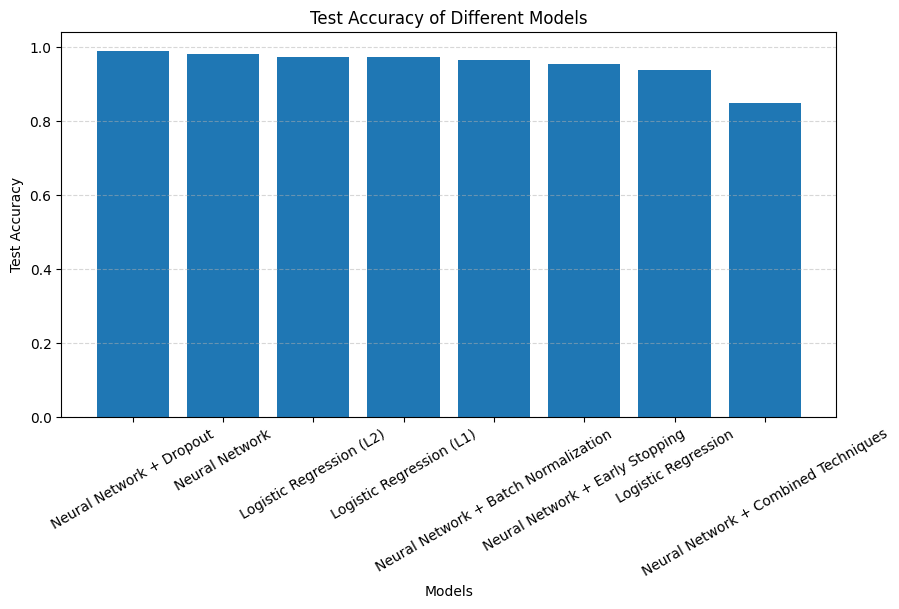

In [18]:
plt.figure(figsize=(10,5))

plt.bar(
    comparison_df["Model"],
    comparison_df["Test Accuracy"]
)

plt.title("Test Accuracy of Different Models")
plt.xlabel("Models")
plt.ylabel("Test Accuracy")

plt.xticks(rotation=30)

plt.grid(axis="y", linestyle="--", alpha=0.5)

plt.show()